# Congestion Pricing and NYC Drivers

On 5 January 2025 New York started charging a toll to enter Manhattan below 60th Street. This notebook measures how the toll changed yellow taxi and high volume for-hire vehicle (Uber/Lyft) trips and driver earnings.

Run it from top to bottom. The functions it calls live in `scripts/`. Setup steps are in `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F

from scripts import (clean, config, download, explore, external, models,
                     plots, spark_io, zones)

# Every figure uses the shared style
plt.style.use(config.STYLE_FILE)

months = config.months_to_process()
print(f"QUICK_RUN = {config.quick_run()}: {len(months)} months, "
      f"{months[0]} to {months[-1]}")

QUICK_RUN = False: 36 months, (2023, 1) to (2025, 12)


/Users/alina/MAST30034-Project1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Download the data

Everything is saved to `data/raw/`. Each download is skipped if its file is already there, so running this section again is quick. The functions are in `scripts/download.py`.

### 1.1 TLC trip data

One parquet file per month for yellow taxis and high volume for-hire vehicle trips (mostly Uber and Lyft), from the [TLC trip record page](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). The full run downloads 72 files (about 20 GB). The table shows rows × columns of every raw file.

In [2]:
tlc_files = download.download_tlc(months)
download.split_large_row_groups(tlc_files)

# Rows x columns of every raw TLC file
tlc_shapes = download.parquet_shapes(tlc_files)
tlc_shapes["service"] = tlc_shapes["file"].str.split("_").str[0]

# Totals per service, for Table 1 in the report
plots.flat(tlc_shapes.groupby("service").agg(
    files=("file", "count"), rows=("rows", "sum"),
    min_columns=("columns", "min"), max_columns=("columns", "max"),
    size_gb=("size_mb", lambda mb: round(mb.sum() / 1000, 1))))

TLC: 72 files, 72 already downloaded, 0 to download


Service,Files,Rows,Fewest columns,Most columns,Size (GB)
High Volume For-Hire Vehicle,36,715550152,24,25,17.3
Yellow Taxi,36,128202548,19,20,2.2


### 1.2 External datasets

Four datasets add the tolled area, the zone map, background speeds and weather to the trip data. The table under the code cell gives rows × columns for each.

| Dataset | Source | Used for | Coverage |
|---|---|---|---|
| Taxi zone lookup and shapefile | [TLC](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Zone names, boroughs and shapes; finding the ring of zones around the CBD (Section 2.1) | 265 zone IDs, 263 with a shape |
| CBD taxi zones | [MTA](https://data.ny.gov/d/yfdc-w5jh) | Which zones are inside the tolled area | 38 zones |
| CBD taxi/FHV speeds | [MTA](https://data.ny.gov/d/6p29-6xqn) | Monthly average speed in the CBD, the CBD-adjacent area and the rest of the city, for one line of background | October 2019 – August 2025, 213 rows |
| Daily weather, Central Park | NOAA GHCN-Daily, station `USW00094728` | Rain, snow and temperature controls in the models | Every day of 2023–2025, in mm and °C |

In [3]:
external_files = download.download_external()

# Rows x columns of each raw external dataset
plots.flat(download.external_shapes(external_files))

Dataset,Files,Rows,Columns
Zone lookup,1,265,4
CBD zones,1,38,2
CBD speeds,1,213,3
Weather,1,1096,7
Zone shapefile,1,263,7


## 2. Prepare the external data

The external datasets are turned into tables that join onto the trips by zone, date or time band: zone labels, weather and holidays.

### 2.1 Zone labels

The analysis compares trips that touch the tolled area (`cbd`) with trips that don't (`control`). Zones just outside the CBD fit neither group. Riders can walk out of the CBD to avoid the toll and drivers can wait at its edge, so these zones may *gain* trips because of the toll. Counting them as control would make the toll's effect look bigger than it is, so they get their own group, the `ring`.

`zone_group_fine` splits the ring and the control group further, for robustness checks:

- **Ring:** zones across the street from the CBD, where a rider can simply walk over the boundary, are kept apart from zones across the river, which are reached by bridge or tunnel.
- **Control:** the control zones nearest the ring are kept apart to test whether the ring is wide enough. If they react to the toll the way the ring does, the ring should be wider (the buffer-band check in Section 6).

The first table counts the zones in each group; the second lists the 19 ring zones.

In [4]:
zone_labels = zones.build_zone_labels()
print(f"Zone labels: {zone_labels.shape[0]} rows x {zone_labels.shape[1]} "
      f"columns, saved to {zones.LABELS_FILE.name}")
display(plots.flat(pd.crosstab(  # noqa: F821
    zone_labels["zone_group_fine"], zone_labels["zone_group"], margins=True,
    margins_name="Total")))

# The ring zones, nearest first
plots.flat(zone_labels[zone_labels["zone_group"] == "ring"]
           .sort_values("distance_to_cbd_ft")
           [["LocationID", "Borough", "Zone", "distance_to_cbd_ft",
             "zone_group_fine"]])

Zone labels: 265 rows x 8 columns, saved to zone_labels.csv


Fine zone group,CBD,Control,Ring,Total
CBD,38,0,0,38
"Control, far",0,190,0,190
"Control, near",0,16,0,16
"Ring, across water",0,0,13,13
"Ring, adjacent",0,0,6,6
Total,38,206,19,263


Zone ID,Borough,Zone,Distance to CBD (ft),Fine zone group
141,Manhattan,Lenox Hill West,0,"Ring, adjacent"
43,Manhattan,Central Park,0,"Ring, adjacent"
237,Manhattan,Upper East Side South,0,"Ring, adjacent"
143,Manhattan,Lincoln Square West,0,"Ring, adjacent"
142,Manhattan,Lincoln Square East,0,"Ring, adjacent"
140,Manhattan,Lenox Hill East,0,"Ring, adjacent"
202,Manhattan,Roosevelt Island,908,"Ring, across water"
145,Queens,Long Island City/Hunters Point,1334,"Ring, across water"
34,Brooklyn,Brooklyn Navy Yard,1374,"Ring, across water"
33,Brooklyn,Brooklyn Heights,1416,"Ring, across water"


In [5]:
# Zone IDs that share a name. The check inside shared_names()
# also confirms that no two zones share a shape, so maps and
# joins keyed on LocationID cannot double-count them.
plots.flat(zones.shared_names(), merge=["zone", "borough"])

### 2.2 Weather and public holidays

Snow, heavy rain and holidays change how many people take a taxi, so weather and holidays are controls in the Section 6 models. Without them, a bad winter after the toll started could look like part of the toll's effect.

- **Weather:** the Central Park station stands in for the whole city, since rain and snow reach every zone on the same day. `rain_mm` is NOAA's total precipitation, so it includes melted snow. The table below shows the range of each column.
- **Holidays:** they are typed out in `external.HOLIDAYS` rather than taken from a package, so the pinned requirements don't grow.

In [6]:
weather = external.load_weather()
print(f"Weather: {weather.shape[0]:,} rows x "
      f"{weather.shape[1]} columns, "
      f"{weather['date'].min():%Y-%m-%d} to "
      f"{weather['date'].max():%Y-%m-%d}")
print(f"Public holidays: {len(external.HOLIDAYS)} dates")
plots.flat(weather.drop(columns="date").describe().round(1)
           .rename_axis("statistic"))

Weather: 1,096 rows x 6 columns, 2023-01-01 to 2025-12-31
Public holidays: 35 dates


Statistic,Rain (mm),Snow (mm),Snow depth (mm),Max temperature (°C),Min temperature (°C)
Count,1096.0,1096.0,1096.0,1096.0,1096.0
Mean,3.4,0.7,1.6,17.9,10.1
Standard deviation,9.6,5.7,8.6,9.5,8.5
Min,0.0,0.0,0.0,-7.1,-16.0
25%,0.0,0.0,0.0,10.0,3.3
50%,0.0,0.0,0.0,17.8,10.0
75%,1.4,0.0,0.0,26.1,17.8
Max,139.2,81.0,102.0,37.2,27.2


## 3. Clean the taxi data

The functions are in `scripts/clean.py`. Every check and outlier cut-off runs on the full data: the cut-offs sit in thin tails (Section 3.5), and some recording problems are concentrated in one vendor's Flex Fare trips in 2025 (Section 3.3), so a sample could miss them.

### 3.1 Read the raw files

`spark_io.read_service` reads every month, keeps only the columns used below and casts them to one schema, so the months can be stacked. The step table in Section 3.7 gives the rows × columns before and after.

In [7]:
spark = spark_io.get_spark()
spark.sparkContext.setLogLevel("ERROR")

# Raw trips with the kept columns, plus trip_seconds, trip_hours, speed_mph
raw = {service: clean.add_trip_time(
           spark_io.read_service(spark, service, months), service)
       for service in config.SERVICES}

# Raw column count for the step table (it differs between years)
raw_columns = {}
for service in config.SERVICES:
    counts = tlc_shapes.loc[tlc_shapes["service"] == service, "columns"]
    low, high = counts.min(), counts.max()
    raw_columns[service] = str(low) if low == high else f"{low}-{high}"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/20 14:41:43 WARN Utils: Your hostname, Alinas-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.0.247 instead (on interface en0)
26/09/20 14:41:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/20 14:41:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/20 14:41:44 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


### 3.2 Nulls

Nulls in every kept column, counted on the full data by month, vendor and (for yellow) payment type. The tables add the months up by year and leave out columns with no nulls.

In [8]:
nulls = {service: clean.null_counts(raw[service], service)
         for service in config.SERVICES}

# Yellow: nulls by year, vendor and payment type
plots.flat(clean.nulls_by_year(nulls["yellow"], ["VendorID", "payment_type"]),
           merge=["year", "VendorID"])

In [9]:
# High Volume FHV: nulls by year and company
plots.flat(clean.nulls_by_year(nulls["fhvhv"], ["hvfhs_license_num"]),
           merge=["year"])

In [10]:
# The yellow table month by month: the four columns are null on every
# Flex Fare row and on no other row, so no row has only some of them null
yellow_nulls = nulls["yellow"]
is_flex = yellow_nulls["payment_type"] == clean.FLEX_FARE
for column in ["passenger_count", "RatecodeID", "congestion_surcharge",
               "airport_fee"]:
    assert (yellow_nulls[column]
            == yellow_nulls["rows"].where(is_flex, 0)).all(), column
print(f"Yellow: the four columns are null on exactly the Flex Fare rows, in "
      f"all {yellow_nulls['file_month'].nunique()} months")

Yellow: the four columns are null on exactly the Flex Fare rows, in all 36 months


**What the null counts show:**

- **Yellow:** only `passenger_count`, `RatecodeID`, `congestion_surcharge` and `airport_fee` ever have nulls, and in every month they're null on exactly the `payment_type` 0 rows (the check above). The data dictionary lists these as Flex Fare trips, a fixed price agreed upfront. `cbd_congestion_fee` is null on every row before 2025, when it was introduced, and on none after.
- **High volume for-hire vehicle:** no nulls, apart from `cbd_congestion_fee` before 2025.

**Decisions:** no row is dropped because of nulls.

- `cbd_congestion_fee` before 2025 stays null. The fee didn't exist, and trips are placed in or out of the zone with the MTA zone list instead.
- The Flex Fare rows are kept. They are real trips, and their share of yellow trips grows fast (Section 3.8), so dropping them would make yellow trips look like they fell after the toll. Their four columns stay null: `passenger_count` isn't used, the `RatecodeID` 99 rule keeps a null rate code (Section 3.7), and the Vendor 1 `extra` rule counts a null fee as 0 (Section 3.4).

### 3.3 Zero and negative yellow fares

Zero and negative `fare_amount` by year, vendor and payment type, for groups with more than 1,000 such rows. A negative fare counts as a reversal when another row has the same vendor, pickup and drop-off times and zones, and the same fare with a positive sign, so the two rows cancel.

In [11]:
# Zero and negative fares by year, vendor and payment type
fares = clean.fare_signs(raw["yellow"])
plots.flat(fares[fares["negative"] + fares["zero"] > 1000],
           merge=["year", "VendorID"])

**What the table shows:**

- **Most negative fares outside Flex Fare are reversals.** Vendor 2's no-charge (3) and dispute (4) payments are about 50% negative, and 88–92% of those negative rows cancel a positive row. So do 88–89% of its negative cash (2) fares. Vendor 1 has almost no negative fares.
- **Vendor 2's Flex Fare trips (payment type 0) are different.** Their negative share jumps from 0.86% in 2023 and 3.94% in 2024 to 20.45% in 2025 (2,047,089 rows), and none of them cancels a positive row.

**Decision:** step 5 of the cleaning (Section 3.7) removes zero and negative fares, except on Flex Fare trips. Those aren't reversals, so they are **kept for trip counts, but their revenue is unknown** (Section 3.8). Dropping them would remove about 4% of 2025 yellow rows.

### 3.4 Yellow `extra`

Revenue for yellow taxis is `fare_amount` plus the part of `extra` that goes to the driver. The TLC fare rules have three such surcharges: $1 overnight (8pm–6am), $2.50 on weekday rush hours (4–8pm) and $5 on LaGuardia trips and JFK flat-fare trips. So the driver's part of `extra` should be 0, 1, 2.50, 5, 6 or 7.50. The data dictionary only calls `extra` "miscellaneous extras and surcharges", so the table below gives its values on more than 1% of a vendor's trips in a year.

In [12]:
# Most common extra values: share of each vendor-year's trips, in %
extra = clean.extra_values(raw["yellow"])
extra_shares = (extra.groupby(["VendorID", "year", "extra"])["count"].sum()
                / extra.groupby(["VendorID", "year"])["count"].sum() * 100)
plots.flat(extra_shares[extra_shares > 1].round(1).rename("pct")
           .reset_index().pivot(index=["VendorID", "extra"], columns="year",
                                values="pct").fillna(0),
           merge=["VendorID"])

**What the table shows:**

- **Vendor 2 (Curb)**, about three quarters of yellow trips (next table): `extra` is 0, 1, 2.50, 5 or 6 on at least 97% of its trips every year, so it holds only the driver surcharges.
- **Vendor 1 (Creative Mobile Technologies)**: the most common non-zero values are 2.50, 3.50 and 5.00 in 2023–2024, and 3.25, 4.25 and 5.75 in 2025. These are the driver surcharges plus the $2.50 congestion surcharge and, from 2025, the $0.75 CBD fee (9.25 also adds the $1.75 airport fee). Vendor 1 puts those city and MTA charges into `extra` **as well as** in their own columns.

**Rule:** for Vendor 1, subtract `congestion_surcharge`, `airport_fee` and `cbd_congestion_fee` from `extra`. If that doesn't leave a valid driver surcharge, try again without subtracting the CBD fee, for rows where Vendor 1 left the CBD fee out of `extra`. Other vendors' `extra` is used as it is. If no valid surcharge is found, the trip's revenue is unknown (null) but the trip is kept. The next table counts how many trips the rule matches, with and without the CBD fee fallback.

In [13]:
# How many trips get a valid driver surcharge, by vendor and year
plots.flat(clean.extra_rule_coverage(raw["yellow"]))

Vendor,Year,Rows,With a surcharge (%),"With a surcharge, no CBD fallback (%)"
1,2023,10037714,99.85,99.85
1,2024,9715918,99.83,99.83
1,2025,9586873,99.86,88.85
2,2023,28263844,99.31,99.31
2,2024,31451503,99.03,99.03
2,2025,38575846,98.91,98.91
6,2023,8668,100.00,100.00
6,2024,2069,80.04,80.04
6,2025,23982,100.00,100.00
7,2024,230,100.00,100.00


The rule finds a valid driver surcharge on over 99.8% of Vendor 1 trips in every year, and on about 99% of Vendor 2 trips. Without the CBD fee fallback, Vendor 1's 2025 share falls to 88.85%, so on about 11% of its 2025 trips the CBD fee was left out of `extra`.

### 3.5 Distributions and outlier cut-offs

Quantiles of trip length (minutes), distance (miles), average speed (mph) and money (`fare_amount` for yellow, `driver_pay` for high volume for-hire vehicle) on every raw trip with a positive time and distance. They are read off full-data histograms with fine bins (0.1 minute, 0.05 mile, 0.1 mph, $0.25), so they are accurate to one bin; values below the first bin show as, for example, `<0.05`. The plots below count every raw trip in coarser bins, with values past either edge added to the end bins so the outliers stay visible.

The median, quartiles and 99.9th percentile of this table, with the cut-offs below it, are **Table 2 of the report**: they are what the report's claim of a right skew and its defence of the cut-offs rest on.

In [14]:
quantiles = {s: clean.distribution_quantiles(raw[s], s)
             for s in config.SERVICES}
plots.flat(pd.concat(quantiles, axis=1))

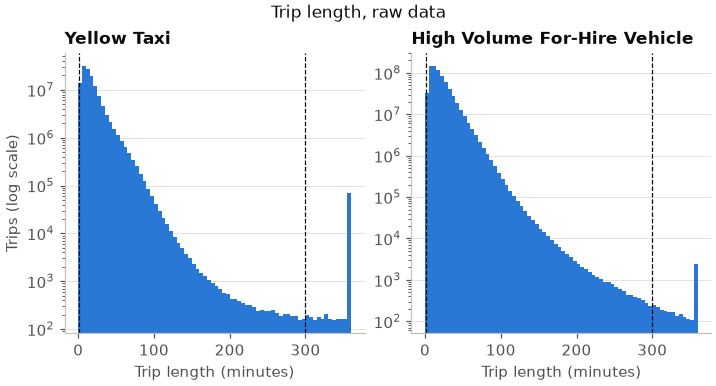

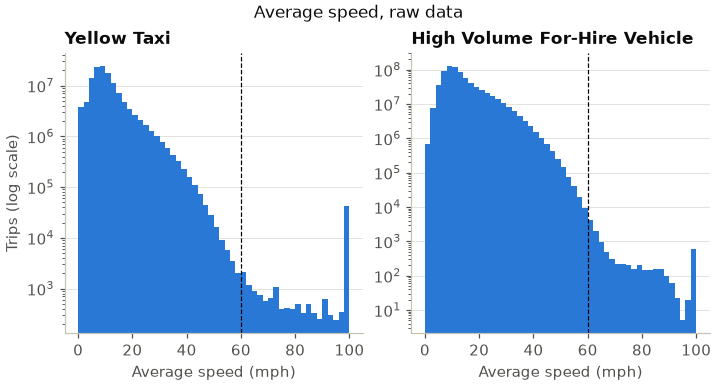

In [15]:
# Full-data histograms of trip length and average speed. Dashed lines are
# the cut-offs in clean.py.
minutes = {s: clean.histogram(raw[s].withColumn("trip_minutes",
                                                F.col("trip_seconds") / 60),
                              "trip_minutes", 0, 360, 5)
           for s in config.SERVICES}
plots.histograms(minutes, [clean.MIN_TRIP_MINUTES, clean.MAX_TRIP_MINUTES],
                 "Trip length (minutes)", "Trip length, raw data")
plt.show()

speeds = {s: clean.histogram(raw[s], "speed_mph", 0, 100, 2)
          for s in config.SERVICES}
plots.histograms(speeds, [clean.MAX_SPEED_MPH], "Average speed (mph)",
                 "Average speed, raw data")
plt.show()

**Cut-offs** (constants at the top of `scripts/clean.py`):

- **Trip length:** at least 1 minute and at most 5 hours. Trips under 1 minute are fewer than 1% of yellow and 0.1% of high volume for-hire vehicle trips (the 1st percentile for yellow and the 0.1th percentile for high volume for-hire vehicle are both 2 minutes). The 99.9th percentile is under 2 hours for both services. Past about 4 hours the yellow histogram flattens into a tail of about 200 trips per 5-minute bin, which looks like meters left running, and the last bin holds every trip of 6 hours or more.
- **Distance:** at most 100 miles. The 99.9th percentile is about 30 miles for yellow and 54 miles for high volume for-hire vehicle.
- **Average speed:** at most 60 mph over the whole trip. The 99.9th percentile is under 50 mph for both services. Above 60 mph the histograms thin out, apart from a pile-up of impossible values of 100 mph or more in the last bin.
- **Money:** `fare_amount` (yellow) or `driver_pay` (high volume for-hire vehicle) at most $500. The 99.9th percentile is about $140–150 for both.

Together the four cut-offs remove 0.80% of yellow rows and 0.02% of high volume for-hire vehicle rows (Section 3.7), so the summary medians don't depend on exactly where the lines sit.

### 3.6 Time bands

The CBD fee on 2025 trips, and the share of trips in each pickup hour on weekdays and weekends. The toll for cars has a peak rate on weekdays from 5am to 9pm (9am to 9pm on weekends) and a lower overnight rate.

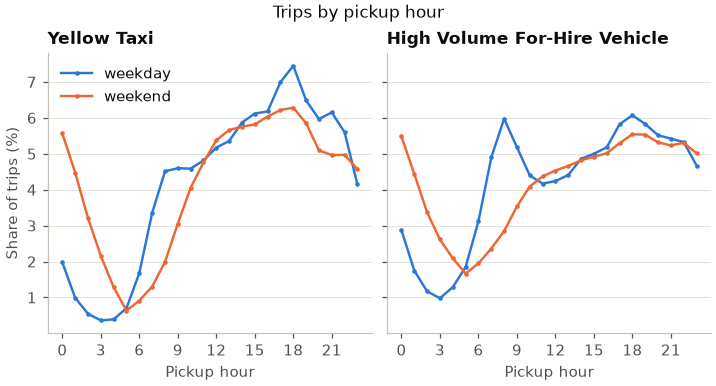

In [16]:
# CBD fee values on 2025 trips, and how many pickup hours each appears in
display(plots.flat(pd.concat({s: clean.cbd_fee_values(raw[s], s)  # noqa: F821
                              for s in config.SERVICES}, names=["service"]),
                   merge=["service"]))

hourly = {s: clean.hourly_counts(raw[s], s) for s in config.SERVICES}
plots.hourly_shares(hourly, "Trips by pickup hour")
plt.show()

The fee has one main value per service in 2025, **$0.75 on yellow trips** and **$1.50 on high volume for-hire vehicle trips**, and it appears in all 24 pickup hours. Apart from 0 (no fee) and -$0.75 on 1% of yellow trips, every other value is on fewer than 200 trips. The fee itself therefore gives no reason to split the day. The bands follow the demand curve and the car toll's hours instead:

| Band | Pickup hours | Why |
|------|-------------|-----|
| `overnight` | 21:00–04:59 | The car toll's off-peak hours. Weekend nights are busy, weekday nights quiet. |
| `morning_peak` | 05:00–09:59 | The weekday toll peak starts at 5am, and weekday trips climb steeply to a peak around 8am |
| `midday` | 10:00–15:59 | Between the peaks, with no sharp peak of its own on either day type |
| `evening` | 16:00–20:59 | The busiest hours, with the yellow $2.50 rush-hour surcharge (4–8pm); the toll peak ends at 9pm |

The same bands are used on every day of the week.

### 3.7 Cleaning

The step table below lists every removal rule in the order it is applied, with its reason and the rows × columns left after it, all from one pass over the full data. The payment type and rate code meanings are from the yellow data dictionary, the outlier cut-offs are from Section 3.5, and the Flex Fare exceptions are explained in Sections 3.2 and 3.3. High volume for-hire vehicle has no payment type, fare or rate code rules; it removes zero or negative `driver_pay` instead.

In [17]:
steps = {}
for service in config.SERVICES:
    steps[service] = clean.step_shapes(raw[service], service,
                                       raw_columns[service])
    print(service)
    display(plots.flat(steps[service]))  # noqa: F821

yellow


Step,Reason,Rows,Columns,Removed,Removed (%)
Raw,Raw files,128202548,19-20,0,0.000
Keep columns,Keep only the columns we need,128202548,14,0,0.000
Pickup in file month,Pickup date outside the month of the file (wrong dates),128201184,14,1364,0.001
Drop-off after pickup,Drop-off time before or equal to pickup time,127625804,14,575380,0.449
Charged trip,"payment_type 3 (no charge), 4 (dispute) or 6 (voided trip): the fare was not collected or the trip is in doubt",124407631,14,3218173,2.510
Positive fare,"Zero or negative fare (mostly reversal rows). Flex Fare trips are kept: their negative fares aren't reversals, so their revenue is set to unknown instead",123959890,14,447741,0.349
Known rate code,RatecodeID 99 (null/unknown). Flex Fare trips have a null RatecodeID and are kept,122483608,14,1476282,1.152
Trip length,Trip shorter than 1 minute or longer than 5 hours,121474771,14,1008837,0.787
Distance cap,Distance over 100 miles,121469987,14,4784,0.004
Speed cap,Average speed over 60 mph (impossible in NYC traffic),121461325,14,8662,0.007


fhvhv


Step,Reason,Rows,Columns,Removed,Removed (%)
Raw,Raw files,715550152,24-25,0,0.000
Keep columns,Keep only the columns we need,715550152,10,0,0.000
Pickup in file month,Pickup date outside the month of the file (wrong dates),715550152,10,0,0.000
Drop-off after pickup,Drop-off time before or equal to pickup time,715519470,10,30682,0.004
Positive driver pay,Zero or negative driver pay,714346062,10,1173408,0.164
Trip length,Trip shorter than 1 minute or longer than 5 hours,714293200,10,52862,0.007
Distance cap,Distance over 100 miles,714228315,10,64885,0.009
Speed cap,Average speed over 60 mph (impossible in NYC traffic),714221992,10,6323,0.001
Money cap,driver_pay over $500,714221778,10,214,0.000
Known zones,"Pickup or drop-off in zone 264 (Unknown) or 265 (Outside of NYC), and the other end is not in the CBD, so the trip group is unknown",694437031,10,19784747,2.765


### 3.8 New columns

`clean.add_columns` adds these to the cleaned trips, next to `trip_hours` from Section 3.1 (drop-off minus pickup, after turning the New York wall-clock times into real instants, so trips across a daylight saving change get the right length):

- `revenue` (yellow only): `fare_amount` plus the driver's part of `extra` (Section 3.4). It leaves out tips and every charge that goes to the city or MTA. Null when the fare is zero or negative (the Flex Fare trips kept in Section 3.3), when no valid driver surcharge was found, or when the trip distance is 0: a meter that didn't measure the distance can't be trusted on the fare either.
- `earnings`: `revenue` for yellow, `driver_pay` for high volume for-hire vehicle, and null on zero-distance trips in both. Those trips are still kept and counted.
- `earnings_per_engaged_hour`: `earnings / trip_hours`. Null when `earnings` is null, and for shared high volume for-hire vehicle trips (`shared_match_flag` = Y), because the same driving time is split over more than one trip.
- `pickup_group`, `dropoff_group`: the five-level `zone_group_fine` from Section 2.1 (`cbd`, `ring_adjacent`, `ring_across`, `control_near`, `control_far`).
- `trip_group`: the first of `cbd` → `ring_adjacent` → `ring_across` → `control_near` → `control_far` that either end falls in, with `cbd` named `treated`. So a trip from `ring_adjacent` to `ring_across` is `ring_adjacent`, and a control trip with either end in `control_near` is `control_near`. The order is one constant, `clean.ZONE_GROUPS`, used here and in the summary table.
- `trip_group_coarse`: `treated` if either end is in the CBD; `ring` if either end is in the ring and neither in the CBD; `control` if both ends are in control zones. The tables below and Figure 1 use it.
- `date`, `hour`, `time_band`, `day_of_week` (1 = Monday), and `after_toll` (pickup date on or after 5 January 2025).

The tables below give the Flex Fare share of yellow trips and the share of trips with known earnings per engaged hour, by year and coarse trip group.

In [18]:
trips = {s: clean.add_columns(clean.clean(raw[s], s), s, spark, zone_labels)
         for s in config.SERVICES}

print("Yellow: Flex Fare share of trips (%), by year and trip group")
flex_by_group = clean.flex_fare_by_group(trips["yellow"])
display(plots.flat(flex_by_group.round(1)))  # noqa: F821

coverage = {}
for service in config.SERVICES:
    print(f"{service}: trips with known earnings per engaged hour (%)")
    coverage[service] = clean.earnings_coverage(trips[service])
    display(plots.flat(coverage[service].round(1)))  # noqa: F821

Yellow: Flex Fare share of trips (%), by year and trip group


Year,Treated,Ring,Control
2023,3.5,3.3,4.1
2024,10.5,8.0,13.2
2025,24.4,19.6,38.1


yellow: trips with known earnings per engaged hour (%)


Year,Treated,Ring,Control
2023,98.8,99.0,98.4
2024,98.7,98.8,98.3
2025,93.8,94.8,92.1


fhvhv: trips with known earnings per engaged hour (%)


Year,Treated,Ring,Control
2023,99.2,99.2,99.4
2024,98.4,98.2,98.4
2025,98.8,98.3,98.0


**What to look for:** if Flex Fare grows at about the same rate in every trip group, its growth can't bias the treated-versus-control comparison. It does **not**: the share of yellow trips booked as Flex Fare went from 3.5% (2023) to 10.5% (2024) to 24.4% (2025) for treated trips and from 3.3% to 8.0% to 19.6% for ring trips, but from 4.1% to 13.2% to **38.1%** for control trips. So the control group changed in a way the toll did not cause, which goes in Limitations.

Earnings per engaged hour is known for 98.3–99.0% of yellow trips in 2023–2024, but only 93.8% of treated and 92.1% of control trips in 2025, the year of the negative Flex Fare fares (Section 3.3). For high volume for-hire vehicle it is known for over 98% of trips in every group and year, so the medians in the summary table rest on nearly all trips.

### 3.9 Summary table

One row per **service × pickup zone × drop-off group (the five `zone_group_fine` values) × date × time band**. The pickup zone and drop-off group together fix the trip group, so control trips are never mixed with trips that touch the ring, and the five trip groups can be compared with a pandas `groupby` instead of a new Spark run. Columns:

- `trips`, `trips_with_earnings` (trips whose revenue or driver pay is known)
- `total_earnings` (revenue for yellow, driver pay for high volume for-hire vehicle)
- `median_earnings_per_engaged_hour`
- `pickup_group`, `trip_group` (five groups), `trip_group_coarse` (`treated`, `ring`, `control`), `after_toll`, `day_of_week`

The median is computed on every trip in the group (`percentile_approx`, within 0.1% of the true rank). Every combination with no trips gets a row with 0 trips and 0 earnings (median left empty), so zeros are not silently missing.

Spark builds the table one month at a time, because every row belongs to a single date. Each month is saved to `data/curated/summary_parts/` and reused on the next run; pass `overwrite=True` after changing a cleaning rule. The full table is saved to `data/curated/trip_summary.parquet`.

In [19]:
summary = clean.build_summary(spark, zone_labels, months)
print(f"Summary table: {summary.shape[0]:,} rows x {summary.shape[1]} "
      f"columns, saved to {clean.SUMMARY_FILE.name}")

# The trips in the summary must equal the rows left after cleaning
for service in config.SERVICES:
    in_summary = summary.loc[summary["service"] == service, "trips"].sum()
    assert in_summary == steps[service]["rows"].iloc[-1], service

print(f"Rows with 0 trips: {(summary['trips'] == 0).mean():.1%}")
plots.flat(summary.groupby(["service", "trip_group",
                            summary["date"].dt.year.rename("year")])["trips"]
           .sum().unstack("year")
           .reindex(list(clean.TRIP_GROUPS.values()), level="trip_group"),
           merge=["service"])

yellow: 36 months summarised


fhvhv: 36 months summarised


Summary table: 11,880,640 rows x 14 columns, saved to trip_summary.parquet


Rows with 0 trips: 37.1%


## 4. Join the external data onto the summary table

This finishes the external data work started in Section 2, but it comes after the cleaning, because it needs the summary table built in Section 3.9. Weather and the holiday flag join on the date. No join may change the number of rows, which the assert inside `join_external` checks.

The result is saved as `data/curated/model_table.parquet`, the table the models in Section 6 are fitted to.

In [20]:
model_table, join_shapes = external.join_external(summary, weather)
display(plots.flat(join_shapes))  # noqa: F821
print(f"Saved to {external.MODEL_TABLE_FILE.name}")

# The joined-on columns, described over the rows that have trips
added = ["rain_mm", "snow_mm", "snow_depth_mm", "temp_max_c",
         "temp_min_c"]
with_trips = model_table[model_table["trips"] > 0]
print(f"Rows on a public holiday: "
      f"{model_table['is_holiday'].mean():.1%}")
plots.flat(with_trips[added].describe().round(1)
           .rename_axis("statistic"))

Step,Rows,Columns
summary table (Step 3),11880640,14
+ daily weather (Central Park),11880640,19
+ public holiday flag,11880640,20


Saved to model_table.parquet


Rows on a public holiday: 3.2%


Statistic,Rain (mm),Snow (mm),Snow depth (mm),Max temperature (°C),Min temperature (°C)
Count,7478126.0,7478126.0,7478126.0,7478126.0,7478126.0
Mean,3.4,0.7,1.6,18.0,10.2
Standard deviation,9.6,5.8,8.8,9.5,8.5
Min,0.0,0.0,0.0,-7.1,-16.0
25%,0.0,0.0,0.0,10.6,3.3
50%,0.0,0.0,0.0,18.3,10.0
75%,1.3,0.0,0.0,26.1,17.8
Max,139.2,81.0,102.0,37.2,27.2


## 5. Explore the data and make maps

Functions are in `scripts/explore.py` (tables) and `scripts/plots.py` (figures). Report figures are saved to `plots/` as PDF.

Unless a subsection says otherwise, before-and-after comparisons use the **toll period, 5 January to 31 December 2025**, against **the same dates in 2024**, so both periods cover the same season and the four pre-toll days of January 2025 are left out. Trip groups are the coarse `treated` / `ring` / `control` of Section 3.8 unless a table says otherwise.

### 5.1 Distributions before and after cleaning

Binned counts of every raw row and every cleaned trip (full data, one Spark pass each). `money` is `fare_amount` for yellow and `driver_pay` for high volume for-hire vehicle in both, so the two curves measure the same thing; the earnings per engaged hour used from Section 3.8 on also adds the driver surcharges to yellow fares, which can only be worked out on clean rows. Values past either end of the range are added to the end bins, so the outliers stay visible.

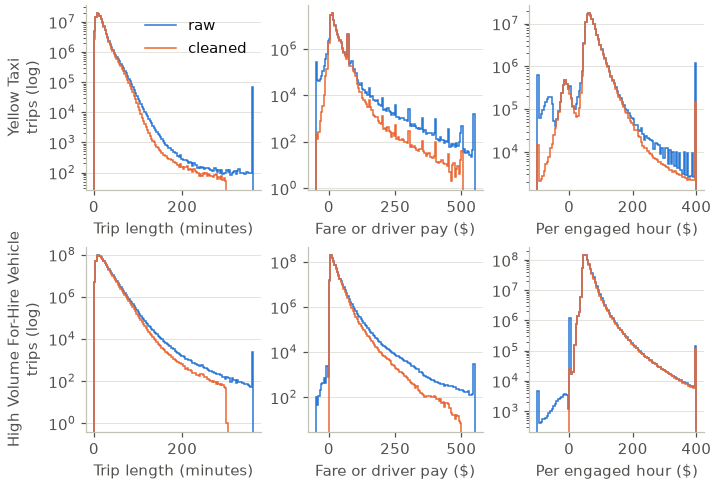

yellow, raw: 0.488% under -$95 an hour, 0.937% at $395 or more
yellow, cleaned: 0.012% under -$95 an hour, 0.123% at $395 or more
fhvhv, raw: 0.001% under -$95 an hour, 0.021% at $395 or more
fhvhv, cleaned: 0.000% under -$95 an hour, 0.017% at $395 or more


In [21]:
money_labels = {"trip_minutes": "Trip length (minutes)",
                "money": "Fare or driver pay ($)",
                "money_per_hour": "Per engaged hour ($)"}
before_cleaning, after_cleaning = {}, {}
for service in config.SERVICES:
    before_cleaning[service] = explore.histograms(
        explore.add_money_columns(raw[service], service), explore.HIST_SPECS)
    after_cleaning[service] = explore.histograms(
        explore.add_money_columns(trips[service], service),
        explore.HIST_SPECS)

plots.before_after_histograms(before_cleaning, after_cleaning, money_labels)
plt.show()

# Share of trips in the end bins of the per-hour histograms
for service in config.SERVICES:
    for name, tables in [("raw", before_cleaning),
                         ("cleaned", after_cleaning)]:
        counts = tables[service]["money_per_hour"]["count"]
        print(f"{service}, {name}: "
              f"{counts.iloc[0] / counts.sum():.3%} under -$95 an hour, "
              f"{counts.iloc[-1] / counts.sum():.3%} at $395 or more")

**What the histograms show:** cleaning cuts the tails and leaves the body alone. The peaks of all six curves are the same before and after.

- **Trip length:** the raw pile in the last bin (357 minutes or more) and the flat tail past 5 hours are gone. Below about 100 minutes the two curves sit on top of each other.
- **Fare or driver pay:** raw yellow has piles in the first bin (under −$45, negative fares, mostly reversals, Section 3.3) and the last ($545 or more). The negative fares left in the cleaned yellow data are Flex Fare trips, kept as trips with unknown revenue (Section 3.3), so they never reach earnings per engaged hour. The yellow spike near $70 matches the JFK flat fare.
- **Per engaged hour:** raw yellow rows pile up at both ends, 0.49% under −$95 an hour (the negative fares) and 0.94% at $395 or more (printed under the figure). Cleaning cuts these to 0.01% and 0.12%. High volume for-hire vehicle has almost no negative values, and its pile at $395 or more barely changes (0.021% of raw rows, 0.017% of cleaned trips), because these trips pass every cleaning rule. Every earnings outcome is a median, so piles this small don't move the results.

### 5.2 Nulls, and what the cleaning removes from each trip group

The null counts are in Section 3.2. As a share of raw rows, by year:

In [22]:
for service in config.SERVICES:
    print(f"{service}: rows with a null (%)")
    display(plots.flat(  # noqa: F821
        explore.null_shares(nulls[service]).round(2)))

yellow: rows with a null (%)


Year,Passengers,Rate code,Congestion surcharge,Airport fee,CBD congestion fee
2023,3.42,3.42,3.42,3.42,100.00
2024,9.94,9.94,9.94,9.94,100.00
2025,23.83,23.83,23.83,23.83,0.00


fhvhv: rows with a null (%)


Year,CBD congestion fee
2023,100
2024,100
2025,0


If a rule removed a bigger share of one trip group after the toll than before, the cleaning itself would move the treated-versus-control comparison. The table below counts each raw row once, under the first rule it fails, as a share of that group's raw rows in the year. `unknown_zone` holds trips with an end in zone 264 or 265 that don't touch the CBD or ring, so they have no group.

In [23]:
removals = {s: explore.removals_by_group(raw[s], s, spark, zone_labels)
            for s in config.SERVICES}
for service in config.SERVICES:
    print(f"{service}: share of each group's raw rows removed (%)")
    display(plots.flat(  # noqa: F821
        explore.removal_shares(removals[service]).round(2)))

yellow: share of each group's raw rows removed (%)


fhvhv: share of each group's raw rows removed (%)


**Nulls:** the only nulls are in the four yellow columns that Flex Fare trips leave blank (Section 3.2), on 3.4% of yellow rows in 2023, 9.9% in 2024 and 23.8% in 2025, and in `cbd_congestion_fee` before 2025, when the column didn't exist.

**What the cleaning removes, by group:**

- **Yellow:** the rules remove more from control trips than from treated trips in every year: 9.2% → 12.8% → 14.7% of control rows, against 2.6% → 3.7% → 5.3% of treated rows. Most of the gap is `RatecodeID` 99 ("Known rate code", 5.3% of control rows in 2024) and payment types 3, 4 and 6 ("Charged trip"). But the before/after comparison uses 2024 against 2025, and between those two years the removed share rose by **1.6 points for treated, 1.8 for ring and 1.8 for control**. Uneven cleaning can therefore account for only about 0.2 points of any yellow treated-versus-control gap. Almost all of the 2025 rise is drop-off at or before pickup (Section 5.3), which takes 1.1 points more of treated rows, 1.4 more of ring rows and 0.8 more of control rows than it did in 2024.
- **High volume for-hire vehicle:** flat in every group. No treated trip is removed for an unknown end any more, because a trip between the CBD and zone 264 or 265 (unknown or outside NYC) is kept (Section 3.7). Ring trips with an unknown end are still removed, 2.21% → 2.18% → 2.38% of ring rows, a rise of 0.2 points between 2024 and 2025, and by definition no control trip is removed this way. So nothing in this table can move the treated-versus-control comparison by more than a rounding error.
- High volume for-hire vehicle driver pay ≤ 0 ("Positive driver pay") removes 0.4–0.5% of each group's rows in 2023 and 0.02–0.03% afterwards. That doesn't touch the 2024/2025 comparison, but it does mean 2023 counts run about 0.4–0.5% low in the event study.

### 5.3 Yellow `VendorID` 7

The share of yellow rows removed for a drop-off at or before the pickup rose from 0.01–0.03% of each group's rows in 2023–2024 to 0.8–1.4% in 2025 (Section 5.2). Almost all of them come from one vendor, `VendorID` 7, which first appears in December 2024. The data dictionary of 18 March 2025 lists vendor 7 as Helix.

In [24]:
vendors = explore.yellow_vendors(raw["yellow"], spark, zone_labels)
vendor_7, vendor_7_groups = explore.vendor_table(vendors, vendor=7, year=2025)
print("Vendor 7 rows, rows with drop-off <= pickup, and share of yellow rows")
display(plots.flat(vendor_7.round(2)))  # noqa: F821
print("Pickup zone group of 2025 rows (%), vendor 7 against all yellow")
plots.flat(vendor_7_groups.round(1))

Vendor 7 rows, rows with drop-off <= pickup, and share of yellow rows


File month,Rows,Drop-off at or before pickup,Share of yellow rows (%)
2024-12-01,230,230,0.01
2025-01-01,1206,1206,0.03
2025-02-01,4420,4420,0.12
2025-03-01,21481,21481,0.52
2025-04-01,33844,33844,0.85
2025-05-01,63261,63261,1.38
2025-06-01,67573,67573,1.56
2025-07-01,55438,55438,1.42
2025-08-01,47276,47276,1.32
2025-09-01,56583,56583,1.33


Pickup zone group of 2025 rows (%), vendor 7 against all yellow


Pickup group,Vendor 7 (%),All yellow (%)
CBD,56.4,56.8
Control,24.2,28.1
Ring,19.3,14.9
NaN,0.0,0.2


**Vendor 7 explains the jump.** It first appears with 230 rows in December 2024 and grows to 1.3–1.6% of yellow rows a month from May 2025: **535,901 rows in 2025**, about 1.1% of that year's raw yellow rows. **Every** one of its rows has the drop-off at or before the pickup, so the rule removes all of them: 536,131 rows, 93% of the 575,380 it removes over the 36 months (Section 3.7). (The data dictionary defines the two times as when the meter was engaged and disengaged, so vendor 7 doesn't record the meter times.) Its pickup zones are filled in (second table), so these are probably real trips.

**Decision: keep the rule.** Without a trip time, trip length, speed and earnings per engaged hour can't be worked out. The removal also creates little treated-versus-control gap: vendor 7's 2025 pickups split across zone groups roughly like all yellow pickups (CBD 56.4% against 56.8%, control 24.2% against 28.1%, ring 19.3% against 14.9%), so the rule takes 1.1% of 2025 treated rows, 1.4% of ring rows and 0.8% of control rows (Section 5.2). It does lower the 2025 yellow totals by about 1.1%, which goes in **Limitations**.

### 5.4 Trips touching the CBD compared with the rest of the city (Figure 1)

Each month's treated trips (and ring trips) divided by its control trips, indexed so each service's 2024 average is 100. Seasons, holidays and citywide changes hit every group, so they mostly cancel in the ratio, and a line that falls after the dashed line means that group lost trips compared with the rest of the city. The first table after the figure gives each year's average of the monthly ratios, and the second the change in trips for the five fine groups.

In [ ]:
relative = explore.relative_trips(summary)
fig = plots.relative_trips(relative, config.TOLL_START_DATE)
plots.save(fig, "fig1_relative_trips")
plt.show()

# Average of the monthly ratios in each year
display(plots.flat(relative.groupby(  # noqa: F821
    ["service", relative["month"].dt.year.rename("year")])
    [["treated", "ring"]].mean().round(1)))

# The same ratio month by month, to check December against other Decembers
ratio = explore.monthly_ratio(relative, "fhvhv")
display(plots.flat(ratio.round(1)))  # noqa: F821
print("October to December, in points: "
      + ", ".join(f"{year} {change:+.1f}"
                  for year, change in (ratio.loc[12] - ratio.loc[10]).items()))

# Trips a day by month, and the change from the same month a year earlier
monthly = explore.monthly_group_trips(summary, "fhvhv")
display(plots.flat(  # noqa: F821
    monthly.loc["2025", ["treated_change_pct", "control_change_pct"]]
    .round(1).rename_axis("month")))

# Trips in the toll period against the same dates in 2024, by fine group
plots.flat(explore.group_change(summary, "trip_group").round(1))

**From Figure 1 we see** that, relative to control trips, high volume for-hire vehicle trips touching the CBD averaged **91.9** in 2025 against 100 in 2024, while ring trips barely moved (97.3). That is about 227,000 treated trips a day before the toll and 219,000 after. **So** the toll cost CBD drivers trips and didn't simply move them into the ring. **But** the treated line was already sliding before the toll: it averaged 107.9 in 2023. Part of the 2025 fall may be a trend the toll didn't cause, and the event study in Section 6 has to test this before the difference-in-differences estimate can be trusted. Yellow treated and ring trips were flat against control before the toll (101.4 and 101.5 in 2023) and fell to **84.8** and **84.2** in 2025. They fell together, **probably because** yellow control trips grew so fast in 2025 (+35%, near and far together in the second table), in step with the Flex Fare growth outside the zone (Section 3.8), not because the toll hit the ring as hard as the CBD: yellow treated trips grew 14.1%.

**December 2025 (82.1) is the lowest point of the line**, and the tables in the next cell say most of it is ordinary:

- December is the low month of the ratio in **every** year (101.6 in 2023, 92.6 in 2024, 82.1 in 2025), and the October-to-December fall is a familiar size: −10.0, −11.3 and −15.8 points.
- What is extra in 2025 is in the **denominator**. December 2025 control trips ran **9.4% above** December 2024, the fastest year-on-year growth of any month in the toll period, while treated trips were only **3.0% below**, a smaller fall than June (−8.0%) or August (−6.4%).

So the December point is a seasonal low read over a fast-growing control group, not a fresh collapse inside the zone. The event study in Section 6.2 compares each month with the same month a year earlier, which is where this is settled.

One more thing for Section 6: by fine group (third table), high volume for-hire vehicle `ring_adjacent` trips were flat (+0.1%) and `ring_across` rose 2.7%, against +5.4% for `control_far`. Both ring halves grew less than the far control zones, so neither shows a clear spillover *gain* at this level. The `control_near` band (+1.0%) also grew much less than `control_far`, which supports running the buffer-band check in Section 6. Yellow `ring_across` doubled (+103%) from a small base (322,154 trips in the 2024 period, against 28.7 million treated), so it says little.

### 5.5 Change by pickup zone (Figures 2 and 3)

Pickups in each pickup zone, toll period against the same dates in 2024. Zones with **fewer than 10 pickups a day** in the 2024 period are greyed out, because their percentage changes rest on too few trips (at 10 a day, about 3,600 trips in the period, chance alone moves a count by about 2%). The inset zooms in on the CBD and the ring. Figure 2 in the report is the high volume for-hire vehicle map; the yellow map is below it.

Earnings per engaged hour is **not** mapped. Its whole range across zones is −1.5 to +5.6%, so a choropleth of it is near-uniform whatever the scale, and what matters is how it moves against pickups. The scatter after the maps shows exactly that and is Figure 3 in the report. Its medians are taken over every trip in Spark, not over the summary table's cell medians.

In [ ]:
zone_medians = {s: explore.zone_medians(trips[s]) for s in config.SERVICES}
zone_changes = {s: explore.zone_change(summary[summary["service"] == s],
                                       zone_medians[s])
                for s in config.SERVICES}
shapes = zones.load_zone_shapes()
too_few = f"Fewer than {explore.MIN_DAILY_PICKUPS} pickups a day in 2024"

# Only pickups are mapped. Earnings per engaged hour move by a few percent,
# so a choropleth of them is near-uniform whatever the scale; the scatter
# below shows the same numbers against pickups, which is what matters
map_limits = {"fhvhv": 15, "yellow": 100}
for service in ["fhvhv", "yellow"]:
    fig = plots.zone_maps(shapes, zone_labels, zone_changes[service],
                          ["change_pct"], ["Change in pickups"],
                          [map_limits[service]], too_few)
    if service == "fhvhv":
        # The report's Figure 2; its caption names the service
        plots.save(fig, "fig2_zone_map")
    else:
        fig.suptitle(plots.SERVICE_NAMES[service])
    plt.show()

for service in config.SERVICES:
    shown = zone_changes[service][zone_changes[service]["enough_trips"]]
    print(f"{service}: {len(shown)} zones shown")
    display(plots.flat(  # noqa: F821
        shown[["change_pct", "eph_change_pct"]].describe().round(1)
        .rename_axis("statistic")))

In [27]:
# Uber/Lyft zones with the biggest changes in pickups, among zones shown
names = zone_labels.set_index("LocationID")[["Zone", "zone_group_fine"]]
shown = (zone_changes["fhvhv"][zone_changes["fhvhv"]["enough_trips"]]
         .join(names, on="PULocationID")
         [["PULocationID", "Zone", "zone_group_fine", "daily_before",
           "change_pct", "eph_before", "eph_after", "eph_change_pct"]])
print("Biggest falls in pickups")
display(plots.flat(  # noqa: F821
    shown.nsmallest(10, "change_pct").round(1)))
print("Biggest rises in pickups")
display(plots.flat(  # noqa: F821
    shown.nlargest(10, "change_pct").round(1)))

# Median of the zone changes in each fine zone group
plots.flat(shown.groupby("zone_group_fine")
           [["change_pct", "eph_change_pct"]]
           .median().round(1).reindex(clean.ZONE_GROUPS))

Biggest falls in pickups


Pickup zone ID,Zone,Fine zone group,"Pickups a day, before",Change (%),"Earnings per hour, before ($)","Earnings per hour, after ($)","Earnings per hour, change (%)"
154,Marine Park/Floyd Bennett Field,"Control, far",68.9,-13.8,61.0,60.2,-1.3
4,Alphabet City,CBD,2051.9,-10.1,54.5,56.3,3.3
224,Stuy Town/Peter Cooper Village,CBD,1454.6,-10.0,53.7,55.8,4.0
79,East Village,CBD,8693.4,-9.0,54.2,56.1,3.5
107,Gramercy,CBD,5196.4,-8.2,53.6,55.2,3.0
120,Highbridge Park,"Control, far",64.6,-8.0,58.4,59.8,2.5
34,Brooklyn Navy Yard,"Ring, across water",609.9,-7.6,53.6,55.6,3.8
114,Greenwich Village South,CBD,4252.3,-7.6,53.9,56.1,4.1
12,Battery Park,CBD,73.8,-7.5,54.6,57.4,5.2
50,Clinton West,CBD,3789.3,-7.5,54.0,55.6,3.0


Biggest rises in pickups


Pickup zone ID,Zone,Fine zone group,"Pickups a day, before",Change (%),"Earnings per hour, before ($)","Earnings per hour, after ($)","Earnings per hour, change (%)"
194,Randalls Island,"Control, far",110.2,26.3,98.1,102.6,4.6
193,Queensbridge/Ravenswood,"Ring, across water",940.9,18.9,53.1,54.4,2.4
99,Freshkills Park,"Control, far",13.8,18.1,65.9,66.4,0.7
57,Corona,"Control, far",136.3,17.5,59.6,59.9,0.6
44,Charleston/Tottenville,"Control, far",250.2,13.7,70.1,69.8,-0.3
29,Brighton Beach,"Control, far",1203.5,13.3,55.3,55.6,0.6
83,Elmhurst/Maspeth,"Control, far",1426.5,13.1,54.3,54.9,1.1
172,New Dorp/Midland Beach,"Control, far",387.4,11.9,58.8,59.9,1.7
101,Glen Oaks,"Control, far",383.0,11.6,67.5,67.6,0.3
106,Gowanus,"Control, far",1300.6,11.4,52.2,53.8,3.2


Fine zone group,Change (%),"Earnings per hour, change (%)"
CBD,-4.3,4.1
"Ring, adjacent",-3.8,2.4
"Ring, across water",2.5,3.5
"Control, near",0.6,2.9
"Control, far",5.9,1.7


In [ ]:
# Figure 3 in the report: the two changes of Figure 2 on one pair of axes
fig = plots.zone_scatter(zone_changes["fhvhv"], zone_labels)
plots.save(fig, "fig3_zone_scatter")
plt.show()

# How the two changes move together, over all zones shown and by group
display(plots.flat(  # noqa: F821
    explore.zone_correlation(zone_changes["fhvhv"], zone_labels).round(2)))

# Earnings per engaged hour in the 38 CBD zones: every one of them rose
cbd_zones = (zone_changes["fhvhv"].join(names, on="PULocationID")
             .query("enough_trips and zone_group_fine == 'cbd'"))
print(f"CBD zones shown: {len(cbd_zones)}, "
      f"{(cbd_zones['change_pct'] < 0).sum()} with fewer pickups, "
      f"{(cbd_zones['eph_change_pct'] > 0).sum()} paying more an hour")
plots.flat(cbd_zones[["eph_before", "eph_after", "change_pct",
                      "eph_change_pct"]].describe().round(2)
           .rename_axis("statistic"))

**From Figure 2 we see** that high volume for-hire vehicle pickups fell in almost every CBD zone (median zone −4.3%) and in the Manhattan zones just north of it (`ring_adjacent`, −3.8%), while they grew in most of the outer boroughs (`control_far` +5.9%). Apart from two small outer-borough zones (under 70 pickups a day) and the Brooklyn Navy Yard, the ten biggest falls are all CBD zones, mostly residential: Alphabet City (−10.1%) and Stuy Town (−10.0%), the East Village (−9.0%), and Gramercy, Greenwich Village South, Battery Park and Clinton West (−7.5 to −8.2%). **So** drivers lost the most rides in the CBD's residential neighbourhoods, **possibly because** trips from there are short, so the flat $1.50 fee is a bigger share of the fare (trip length by zone isn't checked here).

**Median earnings per engaged hour went the other way**, and Figure 3 puts the two changes on one pair of axes. **All 38** CBD zones gained, by **3.0 to 5.6%** an hour (median +4.1%, against +1.7% in the median `control_far` zone), and 33 of the 38 lost pickups at the same time. Over all 256 zones shown the two changes pull against each other (Spearman −0.56) and the CBD sits alone in the top left of the figure: fewer rides, better paid rides.

**Inside the CBD the gain does not follow the loss.** The zones that lost most, Alphabet City (−10.1%) and Gramercy (−8.2%), gained 3.3% and 3.0% an hour, *less* than Midtown Center (+0.7% pickups, +4.9% an hour) or the World Trade Center (+0.5%, +5.6%); within the CBD the two run mildly together (Spearman +0.50). A gain spread that evenly over the zone points to something acting on every trip inside it, such as the faster CBD traffic of Section 5.8, rather than to thinner demand lifting the fares of the zones that emptied. On the 2024 base of $54.65 an hour in the median CBD zone, +4.1% is about $2.20 an hour.

Yellow (second map, notebook only): pickups more than doubled in at least a quarter of the 114 zones shown (upper quartile +226%), mostly outside Manhattan. That is probably the Flex Fare growth outside the zone again (Section 3.8), so the yellow trip map says little about the toll. Yellow revenue per engaged hour fell slightly in the median zone (−2.0%).

The two biggest rises in high volume for-hire vehicle pickups are Randalls Island (+26.3%, a park and event venue with few homes) and Queensbridge/Ravenswood (+18.9%), a `ring_across` zone across the East River from Midtown. Queensbridge is a candidate for the recommendations (a ring zone where drivers could wait for rides), if the model keeps the rise.

### 5.6 Change by time band and day of week (Figure 4)

For each time band and day of week, how much trips touching the CBD changed **on their own** (panel a) and **compared with control trips** (panel b): (1 + treated change) / (1 + control change) − 1. A value of −8 means treated trips ended up 8% lower than if they had changed the way control trips did. It is a raw version of the difference-in-differences estimate in Section 6, with no weather or other controls. Panel (a) is in the figure because the reading below rests on it: the relative panel alone cannot say whether a cell fell or merely grew more slowly than the rest of the city.

Yellow and the control changes behind both services follow, in the notebook only.

In [ ]:
band_day = explore.band_day_change(summary)

# Figure 4 in the report: the treated change on its own, and relative to
# control. Each panel gets its own scale, because (b) is one-signed and a
# scale wide enough for (a) would leave it almost flat
fig = plots.band_day_heatmaps(
    [explore.band_day_table(band_day, "fhvhv", "treated"),
     explore.relative_change(band_day, "fhvhv")],
    ["(a) Treated trips", "(b) Treated against control"],
    limits=[10, (-12, 0)],
    labels=["Change, 2025 vs 2024 (%)", "Treated vs control trips (%)"])
plots.save(fig, "fig4_band_day")
plt.show()

# Yellow, and the control changes behind both services (notebook only)
for service in config.SERVICES:
    tables = [explore.band_day_table(band_day, service, g)
              for g in ["treated", "control"]]
    fig = plots.band_day_heatmaps(
        tables, ["Treated trips", "Control trips"], limits=[30, 90],
        labels=["Change, 2025 vs 2024 (%)"] * 2)
    fig.suptitle(plots.SERVICE_NAMES[service])
    plt.show()

fig = plots.band_day_heatmaps(
    [explore.relative_change(band_day, "yellow")], ["Yellow Taxi"],
    limits=[(-35, 0)], labels=["Treated vs control trips (%)"])
plt.show()

**From Figure 4 we see** that high volume for-hire vehicle trips touching the CBD fell against control trips in **every** time band and day (panel b), by 5–11%. The gap is widest **overnight (−7 to −11%) and at weekends (−8 to −11% on Saturday and Sunday, outside the evening)**, and smallest on weekday mornings (−5 to −6%). **So** the lost trips look more like leisure trips than commutes, **probably because** those riders have more choice about whether and how to go into the zone, while commuters have to be there. Panel (a) is where that reading comes from: on their own, treated trips on Monday to Thursday mornings and middays hardly changed (−1 to +2%), while overnight and weekend treated trips fell 3–10%. Panel (b) is one-signed, so it uses half the diverging scale as a sequential one; panel (a) has both signs and keeps the scale centred at 0.

The report shows this high volume for-hire vehicle pair as Figure 4. Yellow (second figure) shows the same pattern with larger numbers (−8 to −35%, again largest overnight and at weekends), but yellow control trips grew 18–89% depending on the cell (probably the Flex Fare growth of Section 3.8), so the yellow gap is mostly control growth, not a treated fall. Yellow treated trips grew in every cell (+6 to +23%).

For Section 6: the time-band model should find the largest effect overnight. If it doesn't, weather or the day-of-week mix is doing more than this raw comparison suggests.

### 5.7 High volume for-hire vehicle pickup wait

The time from a ride request to the pickup (`pickup_datetime` minus `request_datetime`). `on_scene_datetime`, when the driver arrives, would be closer to what we want, but the data dictionary says it is only recorded for accessible vehicles. A longer wait suggests fewer free drivers for the passengers asking; a shorter one, more drivers than passengers.

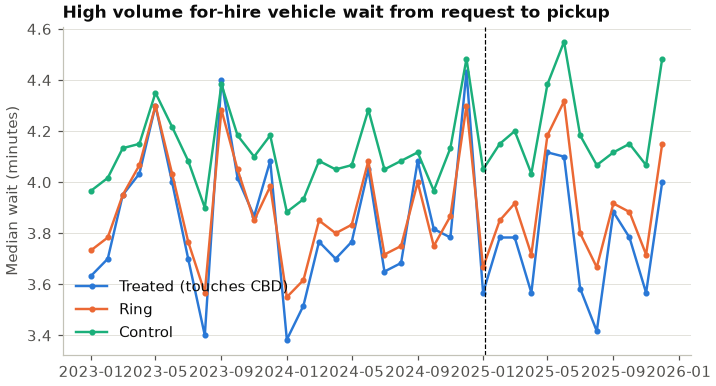

Pickup before request: 7,023,122 trips (1.011%)


In [29]:
wait = explore.pickup_wait(trips["fhvhv"])
wait_medians = wait.pivot(index="month", columns="trip_group_coarse",
                          values="median_wait_min")[clean.COARSE_TRIP_GROUPS]
plots.monthly_lines(wait_medians, "Median wait (minutes)",
                    "High volume for-hire vehicle wait from request to pickup",
                    config.TOLL_START_DATE)
plt.show()

print(f"Pickup before request: {wait['negative'].sum():,} trips "
      f"({wait['negative'].sum() / wait['trips'].sum():.3%})")
# Average of the monthly medians and 90th percentiles, by year
plots.flat(wait.assign(year=wait["month"].dt.year)
           .groupby(["year", "trip_group_coarse"])
           [["median_wait_min", "p90_wait_min"]]
           .mean().unstack("trip_group_coarse").round(2))

Waits inside the zone got slightly **shorter** relative to the rest of the city. Averaged over each year's monthly medians, the wait for treated trips went from 3.80 minutes in 2024 to 3.76 in 2025, while control waits went from 4.09 to 4.20. The 90th percentile tells the same story more strongly: 8.12 → 7.99 minutes for treated trips, 7.98 → 8.58 for control. Shorter waits with fewer trips point to **more free drivers per passenger in the zone**. So each driver in the CBD may be getting fewer rides per hour online, which earnings per engaged hour can't show, because trip records have no idle time.

About 1.0% of trips (7.0M) have the pickup before the request. They are left out of the waits, and they may be trips booked while the rider was already in the car, or clock differences.

### 5.8 What an engaged hour buys

Earnings per engaged hour is earnings divided by the time from pickup to drop-off, so it rises either because trips pay more or because the same hour covers more ground. The trips themselves can tell the two apart. The first table gives the median speed, distance, length and pay per engaged hour of high volume for-hire vehicle trips **picked up** in the CBD, the ring and the control zones, before and after the toll. It also gives the share of trips that have no engaged hour of their own: shared rides, where two trips share one driver's hour, and the trips of Section 3 whose distance was never measured.

The second table is the outside check. It is the MTA's monthly average taxi and for-hire vehicle speed in the CBD, the area next to it and the rest of the city (Section 1.2), which measures every vehicle rather than only the ones carrying a passenger. The file ends in August 2025, so January–August 2025 is compared with the same months of 2024.

In [ ]:
# Speed, distance and pay of the same trips that produced the
# earnings change of Section 5.5, by the group they were picked up in
engaged_hour = explore.engaged_hour_by_group(trips["fhvhv"])
display(plots.flat(engaged_hour.round(2)))  # noqa: F821

# The same table as before, after and the change between them
plots.flat(explore.engaged_hour_change(engaged_hour).round(2),
           merge=["measure"])

In [30]:
plots.flat(explore.speed_change(external_files["cbd_speeds"]).round(2))

Zone,Before (mph),After (mph),Change (%)
CBD,8.74,9.01,3.09
CBD Adjacent,12.60,12.46,-1.12
Greater NYC,16.66,16.52,-0.90


**From the first table we see** that the median trip picked up in the CBD ran **2.1% faster** after the toll (10.01 → 10.23 mph) and covered **2.9% more ground** (2.80 → 2.88 miles) in the same 18.3 minutes, while control pickups went 1.4% slower over 2.7% less ground and ring pickups barely moved (−0.2% and −1.3%). **So** an engaged hour in the CBD buys more distance than it used to, **which is why** median earnings per engaged hour there rose 4.1% ($54.88 → $57.13) against 1.8% for control pickups: the fare pays for distance, and thinner demand in the emptiest zones is not needed to explain it (Section 5.5).

The MTA's independent measure agrees. Traffic in the CBD got **3.1% faster** (8.74 → 9.01 mph) over January–August, while the area next to it (−1.1%) and the rest of the city (−0.9%) got slightly slower.

Shared rides are 1.1–1.9% of trips in every group and period, so leaving them out of earnings per engaged hour (Section 3.8) drops a small and roughly even slice of each group; the measure is known for at least 98% of trips throughout.

## 6. Models

Both models are fitted to the model table of Section 4, separately for each service. The trip groups are those of Section 3.8: `treated`, the two ring halves (`ring_adjacent`, `ring_across`) and control (`control_near` and `control_far` together). Pickup zone, drop-off group, time band, day of week and month are **categorical** inputs; rain, snowfall, snow depth and the maximum and minimum temperature are **continuous**; the holiday flag is 0 or 1. The functions are in `scripts/models.py`.

Every effect is given in percent relative to control trips. Model 1's coefficients are on the log scale, so a coefficient *b* is a change of 100 × (e<sup>*b*</sup> − 1)%.

### 6.1 Model 1: difference-in-differences

Trips touching the CBD are compared with control trips, before and after 5 January 2025. Ring trips are kept out of the control group, because the toll may have moved trips into the ring; each ring half gets its own after-toll term instead, which measures that spillover.

- **Trips:** a Poisson regression of trips per cell (pickup zone × drop-off group × date × time band), because many cells have 0 trips (Section 3.9) and log(0) is undefined.
- **Earnings per engaged hour:** OLS on the log of each cell's median, weighted by the cell's trips with known earnings, so a cell with one trip counts less than a cell with a thousand.
- **Fixed effects** for each pickup zone × drop-off group × time band, which absorb the trip group and each cell's usual level, and for each date × time band, which absorb the after-toll flag, day of week, holidays and citywide weather, separately for each band.
- **`treated` × each weather column**, in case weather changes demand inside the CBD differently from the rest of the city.
- **Standard errors clustered by pickup zone**, because days from the same zone are not independent (Bertrand, Duflo and Mullainathan, 2004).

`did_checks` fits this headline model and every variant and check in Sections 6.3–6.4, for both outcomes. The table shows the headline terms and, beside them, the same model with one pooled ring term. `Rows` is the number of rows each fit used: the Poisson fit leaves out cells with no trips on any day, which carry no information about change.

In [31]:
did_effects = pd.concat(
    {s: models.did_checks(models.did_data(model_table, s))
     for s in config.SERVICES}, names=["service"])
effect_columns = ["effect_pct", "ci_low_pct", "ci_high_pct"]

# Headline toll terms, and the pooled ring term of the same model
plots.flat(did_effects.query("check in ['headline', 'pooled ring']")
           [effect_columns + ["rows"]].droplevel("term").round(1),
           merge=["service", "outcome", "check"])

**High volume for-hire vehicle:** in the headline model, trips touching the CBD were **10.8% lower** than control trips would suggest (95% CI −12.0 to −9.6%), and earnings per engaged hour **2.2% higher** (1.9 to 2.5%). Only the Manhattan half of the ring lost trips: `ring_adjacent` −6.4% (−8.1 to −4.7%), against `ring_across` −0.7%, whose interval includes 0. The pooled ring term (−2.6%) sits between the two and understates the loss next to the CBD, which is why the split is kept.

**Yellow:** treated trips −16.3%, with a wide interval (−29.5 to −0.8%), and `ring_adjacent` −20.7%. Yellow treated trips still grew in 2025 (Section 3.9), so these are falls relative to fast-growing control trips, not absolute falls. Uneven cleaning accounts for about 0.2 points (Section 5.2). `ring_across` (+55.7%) rests on few trips, 325,206 in 2024 (Section 3.9). Revenue per engaged hour of treated trips rose 4.2% (2.8 to 5.6%).

### 6.2 Event study (Figure 5)

The headline model gives one number for the whole toll period. Here the trips model is fitted again with a `treated`, `ring_adjacent` and `ring_across` term for every month, relative to December 2024. If trips inside and outside the zone were following the same trend before the toll (the parallel trends assumption), the points before the dashed line sit near 0.

The trips are summed to months first, with a fixed effect for each cell and each month × time band, because 105 month terms on the 5.8M daily rows of a service would need about 5 GB per copy of the data. There is no weather term: monthly weather has one value per month, which the month terms already absorb.

The first table gives the treated estimates by calendar month and year; the second, the change from the same month a year earlier, in percentage points.

INFO:fontTools.subset:maxp pruned


INFO:fontTools.subset:cmap pruned


INFO:fontTools.subset:kern dropped


INFO:fontTools.subset:post pruned


INFO:fontTools.subset:FFTM dropped


...

INFO:fontTools.subset:glyf pruned


INFO:fontTools.subset:GDEF pruned


INFO:fontTools.subset:GPOS pruned


INFO:fontTools.subset:GSUB pruned


INFO:fontTools.subset:name pruned


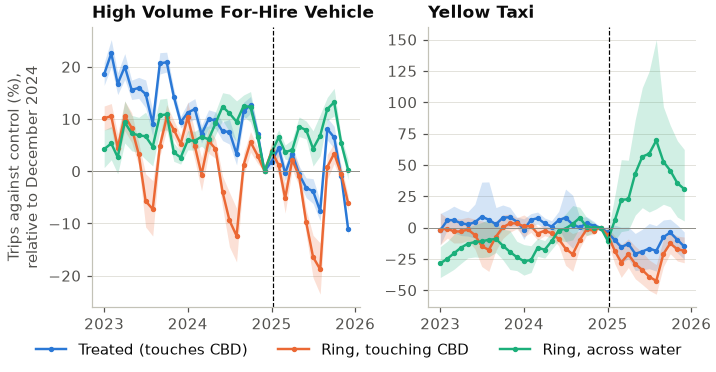

In [32]:
events = {s: models.event_study(model_table, s) for s in ["fhvhv", "yellow"]}
fig = plots.event_study(events, config.TOLL_START_DATE)
plots.save(fig, "fig5_event_study")
plt.show()

treated = (pd.concat(events, names=["service"]).reset_index("service")
           .query("group == 'treated'"))
by_month = treated.pivot_table(
    index=treated["month"].dt.month.rename("month_of_year"),
    columns=["service", treated["month"].dt.year.rename("year")],
    values="effect_pct")
display(plots.flat(by_month.round(1)))  # noqa: F821

# Change from the same month a year earlier (percentage points)
same_month = by_month.T.groupby(level="service").diff().dropna()
plots.flat(same_month.agg(["min", "mean", "max"], axis=1).round(1),
           merge=["service"])

**From Figure 5 we see** that the parallel trends assumption fails for high volume for-hire vehicle trips. The treated estimates were already falling before the toll: every month of 2024 sits 5.8–10.7 points below the same month of 2023, and 2025 sits 3.4–11.4 points below 2024 (second table, means −8.2 and −8.6). **So** the fall in the toll year is about the same size as the fall in the year before it, **probably because** whatever was already moving these trips away from the CBD in 2023–2024 carried on; this notebook doesn't identify what that was. Section 6.3 puts a number on it.

The September–October 2025 rebound noted in Section 5.4 is at least partly seasonal: September and October were also high in 2023 (20.6 and 20.9) and 2024 (11.5 and 12.7). December 2025 (−11.1) is the lowest month of the timeline, but December was also the lowest month of 2023 and 2024.

Yellow treated trips have no such pre-trend: 2024 sits between 6.8 points below and 1.7 above the same months of 2023 (mean −1.7). In 2025 they fall 2.3–25.1 points below 2024 (mean −16.0), by 21–25 points in March and in May to August (first table).

### 6.3 Checks on the headline estimate

Four checks:

- **Placebo:** 2023–2024 only, with a fake toll on 5 January 2024. There was no toll, so any "effect" found is a trend or chance.
- **2024–2025 only:** the toll period against 2024 alone, so a trend that ran through 2023 moves the estimate less.
- **Linear trends:** the headline model plus a straight-line trend for the treated group and each ring half (the `trend` rows, change per year). The toll terms then measure the break from each group's own trend.
- **Buffer band dropped:** control trips with an end in `control_near`, the 16 control zones between 1 and 2 km from the CBD that the toll may also have reached, are left out, so both ends of every remaining control trip are more than 2 km away.

In [33]:
checks = ["headline", "placebo", "2024-2025 only", "linear trends",
          "buffer band dropped"]
plots.flat(did_effects.query("check in @checks")[effect_columns + ["rows"]]
           .round(1), merge=["service", "outcome", "check"])

**High volume for-hire vehicle trips:** the placebo finds an "effect" of −6.4% (−7.0 to −5.7%) in 2024, when there was no toll, and the treated trend is −7.1% a year. Comparing 2025 with 2024 alone gives −7.6%, not much more than the placebo year. With the trends in the model, the effect on treated trips shrinks to **−0.4% (−1.3 to +0.6%)**, and `ring_adjacent` to +1.0% (−0.8 to +2.8%). **So the toll itself cost trips touching the CBD little, if anything, beyond a decline that had already started.** Dropping the buffer band barely moves the headline (−11.4% against −10.8%), so control zones near the CBD aren't hiding a larger effect.

**High volume for-hire vehicle earnings per engaged hour** hold up: the placebo is −0.3% (−0.5 to −0.0%), 2025 against 2024 alone +2.4%, with trends +1.6% (1.2 to 1.9%), and without the buffer band +2.4%.

**Yellow trips:** no treated placebo effect (−1.5%, −7.7 to +5.1%) and no clear treated trend (−1.4% a year, −5.6 to +3.0%), so the treated estimate stays near −15% (−15.6% for 2024–2025, −14.5% with trends). It does depend on the control group: without the buffer band it grows to −27.3% (−47.1 to −0.1%), because far control trips grew much faster than near ones (Section 3.9). `ring_across` has a strong upward trend (+18.8% a year) and a placebo of +11.9%, so its rise isn't a toll effect. Yellow revenue per engaged hour: placebo +0.4% (−0.2 to +0.9%), +4.0% for 2024–2025, +4.1% with trends and +5.5% without the buffer band.

### 6.4 Toll effect by time band

The headline model again, with one treated and one ring term for each time band in place of the whole-day terms. The ring is pooled here, to keep the number of terms down. Because the date fixed effects are separate for each band, each term picks up only the change in that band, not the usual differences between bands.

In [34]:
plots.flat(did_effects.query("check == 'by time band'")[effect_columns]
           .droplevel("check").round(1),
           merge=["service", "outcome", "group"])

High volume for-hire vehicle treated trips fell most **overnight (−11.8%)** and least in the **morning peak (−8.7%)**, with midday (−10.9%) and evening (−11.1%) between. Overnight is the largest, as Figure 4 suggested (Section 5.6). Ring trips fell 2.5–2.9% in every band. Earnings per engaged hour of treated trips rose in every band, from +1.9% overnight to +2.6% midday. Like the headline model, this fit has no trend terms, so these effects still carry the pre-trend of Section 6.3.

Yellow also falls most overnight (−25.9%, −45.1 to +0.2%), with wider intervals, but the morning peak comes next (−21.1%) and the evening falls least (−10.9%, −22.9 to +3.1%).

### 6.5 Earnings per engaged hour in dollars

Model 1's headline percentage for treated trips, times the median earnings per engaged hour of every treated trip in the 2024 period (5 January to 31 December 2024), from Spark.

In [35]:
headline_eph = did_effects.xs(("log_eph", "headline", "treated", "all"),
                              level=["outcome", "check", "group", "term"])
for service in config.SERVICES:
    median = models.median_eph_before(trips[service])
    effect = headline_eph.loc[service]
    print(f"{service}: 2024 median ${median:.2f} an hour; "
          f"{effect['effect_pct']:+.1f}% is "
          f"{median * effect['effect_pct'] / 100:+.2f} $ an hour "
          f"(95% CI {median * effect['ci_low_pct'] / 100:+.2f} to "
          f"{median * effect['ci_high_pct'] / 100:+.2f})")

yellow: 2024 median $69.34 an hour; +4.2% is +2.91 $ an hour (95% CI +1.94 to +3.90)


fhvhv: 2024 median $55.26 an hour; +2.2% is +1.23 $ an hour (95% CI +1.07 to +1.39)


At the 2024 median, the 2.2% rise is about **$1.23 more per engaged hour** for high volume for-hire vehicle drivers on trips touching the CBD ($55.26 → about $56.49; 95% CI +$1.07 to +$1.39). Yellow revenue per engaged hour rose about $2.91 ($69.34 → about $72.25). These are per hour *with a passenger*, so they leave out the idle time that Section 5.7 points to.

### 6.6 Model 2: LightGBM forecast

LightGBM (Ke et al., 2017) is a gradient boosting method: it adds up hundreds of small decision trees, each fitted to the errors left by the trees before it. It finds interactions, such as a zone that is busy only on weekend nights, without them being written into the model. Here it forecasts each cell's trips, and separately its total earnings, from:

- the inputs listed at the start of Section 6;
- `year`, as a number;
- `usual`: the cell's mean over the training rows only, so no later data leaks in.

Trips are counts, so the trips model uses a Poisson objective. Total earnings are 0 in cells with no trips and continuous otherwise, which a Tweedie objective fits. The settings (300 trees, learning rate 0.1, 63 leaves; `models.LGBM_PARAMS`) were not tuned.

**Validation:** train on 2023 and test on all of 2024, both before the toll, so every month of the test year also appears in training. MAE and RMSE are per cell and day. WMAPE is the sum of absolute errors as a share of the sum of actual values; plain MAPE breaks on cells with very few trips. The baseline forecasts each cell with its value on the same weekday 52 weeks earlier.

In [36]:
validation = {s: models.validate(model_table, s) for s in config.SERVICES}
plots.flat(pd.concat({s: v[0] for s, v in validation.items()},
                     names=["service"]).round(2),
           merge=["service", "target"])

For high volume for-hire vehicle, the model beats the baseline on every measure: WMAPE 13.7% against 15.0% for trips, and 17.9% against 19.3% for total earnings. For yellow it doesn't clearly: the baseline is slightly better on trips (WMAPE 20.8% against 21.2%, MAE 4.08 against 4.15), the model slightly better on RMSE and on total earnings (WMAPE 23.9% against 24.4%). So Model 2's yellow trip forecasts are no better than the same day a year earlier.

In [37]:
# Pickup zones with the largest sums of absolute errors in 2024 (trips)
for service in config.SERVICES:
    print(service)
    display(plots.flat(  # noqa: F821
        models.zone_errors(model_table, validation[service][1], service)
        .join(names["Zone"]).round(1)))

yellow


Pickup zone ID,Abs error share (%),Trips,Predicted,Bias (%),Change (%),Zone
161,4.1,1848141,1698632.6,-8.1,7.3,Midtown Center
237,4.1,1854630,1722992.6,-7.1,6.1,Upper East Side South
236,3.9,1682855,1542542.0,-8.3,7.8,Upper East Side North
132,3.7,1715253,1788036.7,4.2,-4.5,JFK Airport
138,3.0,1218932,1226703.0,0.6,-2.1,LaGuardia Airport
230,3.0,1319687,1218121.6,-7.7,7.6,Times Sq/Theatre District
162,2.9,1371400,1304657.5,-4.9,3.8,Midtown East
186,2.9,1308974,1265233.2,-3.3,3.0,Penn Station/Madison Sq West


fhvhv


Pickup zone ID,Abs error share (%),Trips,Predicted,Bias (%),Change (%),Zone
138,2.3,4137664,3802380.5,-8.1,8.4,LaGuardia Airport
132,1.6,3496756,3552029.4,1.6,-1.5,JFK Airport
161,1.5,2803718,2864566.0,2.2,-3.5,Midtown Center
79,1.5,3171008,3260602.6,2.8,-3.6,East Village
230,1.4,2938711,2894930.5,-1.5,1.1,Times Sq/Theatre District
246,1.3,2569380,2565091.7,-0.2,-0.8,West Chelsea/Hudson Yards
231,1.3,2712534,2701634.7,-0.4,-1.5,TriBeCa/Civic Center
112,1.3,2253270,1986397.1,-11.8,12.2,Greenpoint


The largest errors are in busy zones whose trips changed between 2023 and 2024, and in most of them the error is about that change with the sign flipped: trained on 2023 alone, the model forecasts roughly 2023's level. For high volume for-hire vehicle, LaGuardia Airport grew 8.4% and was forecast 8.1% low (2.3% of all absolute errors), and Greenpoint grew 12.2% and was forecast 11.8% low. For yellow, Midtown Center, the two Upper East Side zones and Times Square grew 6.1–7.8% and were forecast 7.1–8.3% low.

### 6.7 Forecast of the toll period

Model 2 is refitted on 2023–2024 and forecasts every cell and day of the toll period. `year` lets the refit follow the change from 2023 to 2024; trees can't extrapolate, so 2025 is forecast as a year like 2024. (In the validation fit, `year` was 2023 on every training row, so it played no part there.)

The gap between actual and forecast also holds everything that changed citywide in 2025, such as rideshare growth, so the toll effect is each group's gap relative to the gap for control trips: (1 + group gap) / (1 + control gap) − 1. That is on the same scale as Model 1.

In [38]:
forecasts, shap_values = {}, {}
for service in config.SERVICES:
    for target in models.OBJECTIVES:
        model, inputs, rows = models.forecast(model_table, service, target)
        forecasts[service, target] = rows
        if target == "trips":
            shap_values[service] = models.shap_importance(model, inputs)

plots.flat(pd.concat({key: models.forecast_effect(rows)
                      for key, rows in forecasts.items()},
                     names=["service", "target"]).round(1),
           merge=["service", "target"])

High volume for-hire vehicle control trips came in above forecast (far +5.5%, near +1.5%) and treated trips 3.8% below, so treated trips were **8.3% lower** relative to control. Total earnings of treated trips were 3.0% above forecast, **3.8% lower** relative to control.

Yellow: treated trips −15.3% and `ring_adjacent` −20.8% relative to control, with far control trips 57.6% above forecast.

### 6.8 Which inputs matter (SHAP)

SHAP values (Lundberg and Lee, 2017) split each forecast into one additive part per input, so an input's mean absolute SHAP value measures how far it moves the forecasts. They are for the two trips models, on the log scale of the Poisson objective, over a random sample of 20,000 toll-period rows, because their run time grows with the number of rows.

In [39]:
plots.flat(pd.DataFrame(shap_values).sort_values("fhvhv", ascending=False)
           .round(3).rename_axis("input"))

Input,Yellow Taxi,High Volume For-Hire Vehicle
Usual level,2.898,2.091
Day of week,0.077,0.099
Time band,0.029,0.033
Pickup zone ID,0.032,0.028
Month,0.128,0.018
Year,0.213,0.011
Max temperature (°C),0.011,0.011
Dropoff group,0.006,0.009
Min temperature (°C),0.012,0.007
Rain (mm),0.006,0.006


`usual`, the cell's usual level, moves the forecasts far more than anything else (2.091 for high volume for-hire vehicle, 2.898 for yellow). Next come day of week (0.099), time band (0.033) and pickup zone (0.028) for high volume for-hire vehicle, and year (0.213), month (0.128) and day of week (0.077) for yellow. Weather matters little in either model (at most 0.012).

### 6.9 The two models compared (Table 2)

Each model's toll effect relative to control trips, for the whole day, for treated trips in each time band and for each ring half. Model 1's effects come from the headline and time-band fits, with 95% intervals; Model 2 has no interval. Model 1 measures earnings per engaged hour and Model 2 total earnings, so those two columns answer different questions.

In [40]:
table_2 = pd.concat(
    {s: models.comparison(did_effects.loc[s],
                          {t: forecasts[s, t] for t in models.OBJECTIVES})
     for s in ["fhvhv", "yellow"]}, names=["service"])
plots.flat(table_2.round(1), merge=["service", "group"])

**Size inside the zone:** for high volume for-hire vehicle, Model 2's −8.3% lies between Model 1's headline (−10.8%) and its 2024–2025 fit (−7.6%, Section 6.3). That fits how it is built (Section 6.7): it mainly compares the toll year with 2024. Neither model removes the pre-trend of Section 6.3. For yellow the two agree closely (−16.3% and −15.3%).

**Time bands:** both models put the largest high volume for-hire vehicle fall overnight (Model 1 −11.8%, Model 2 −9.2%) and the smallest in the morning peak (−8.7% and −6.2%). For yellow, both have overnight largest and evening smallest.

**Ring:** both find the high volume for-hire vehicle loss on the Manhattan side only (`ring_adjacent` −6.4% and −4.2%, `ring_across` −0.7% and −0.9%).

**Earnings:** the two earnings columns fit together. High volume for-hire vehicle earnings per engaged hour of treated trips rose 2.2% (Model 1), while their total earnings fell 3.8% relative to control (Model 2), less than their trips (−8.3%).